In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
!pip install seaborn

In [8]:
import seaborn as sns

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('/content/Unemployment in India.csv')

print(df.head())
print(df.shape)
print(df.columns)

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
(768, 7)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%

In [12]:
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    -------

In [13]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [14]:
df = df.dropna()

print("Dataset shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dataset shape after cleaning: (740, 7)

Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [15]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print(df['Date'].head())

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


/tmp/ipykernel_1495/90546014.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [16]:
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500

In [17]:
monthly_unemployment = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

print(monthly_unemployment.head())

        Date  Estimated Unemployment Rate (%)
0 2019-05-31                         8.874259
1 2019-06-30                         9.303333
2 2019-07-31                         9.033889
3 2019-08-31                         9.637925
4 2019-09-30                         9.051731


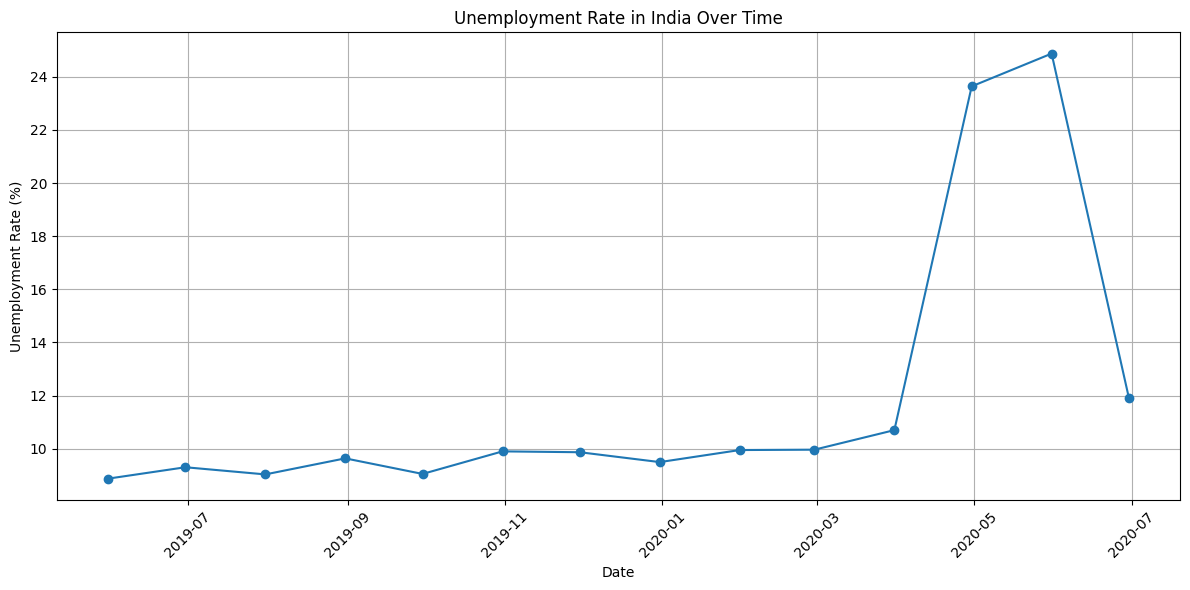

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment['Date'],
    monthly_unemployment['Estimated Unemployment Rate (%)'],
    marker='o'
)

plt.title('Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
region_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print(region_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


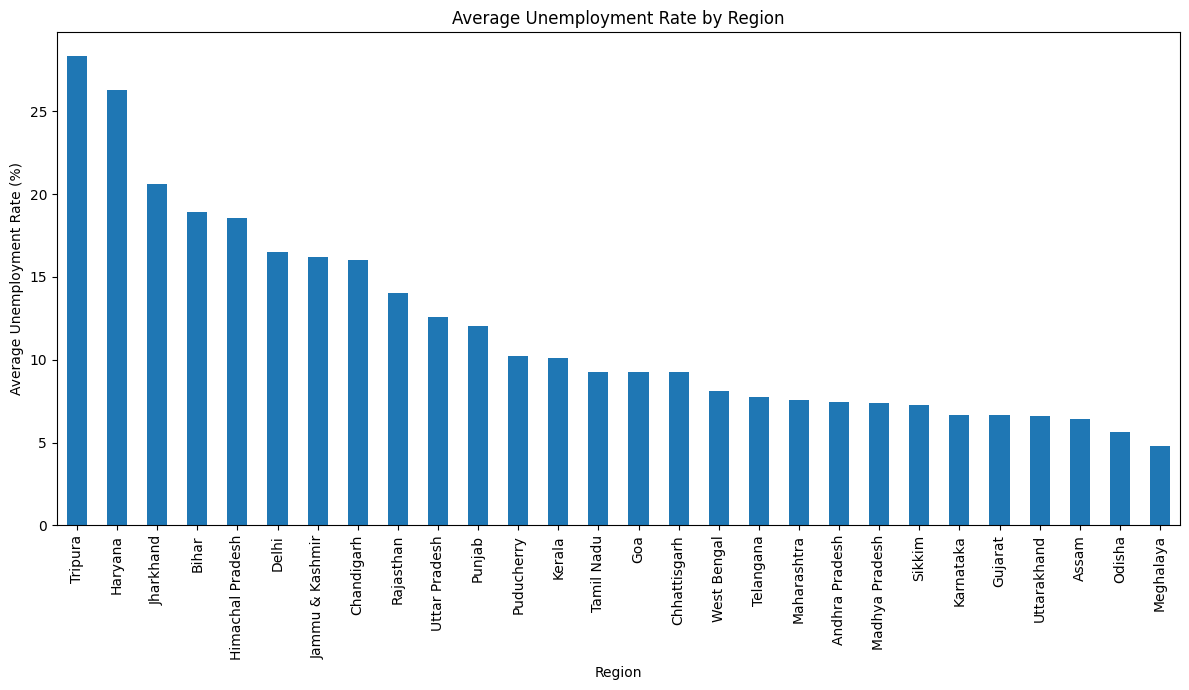

In [20]:
plt.figure(figsize=(12, 7))

region_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
print("Top 10 Regions with Highest Average Unemployment:")
print(region_unemployment.head(10))

Top 10 Regions with Highest Average Unemployment:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


In [22]:
area_unemployment = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print(area_unemployment)

Area
Urban    13.166614
Rural    10.324791
Name: Estimated Unemployment Rate (%), dtype: float64


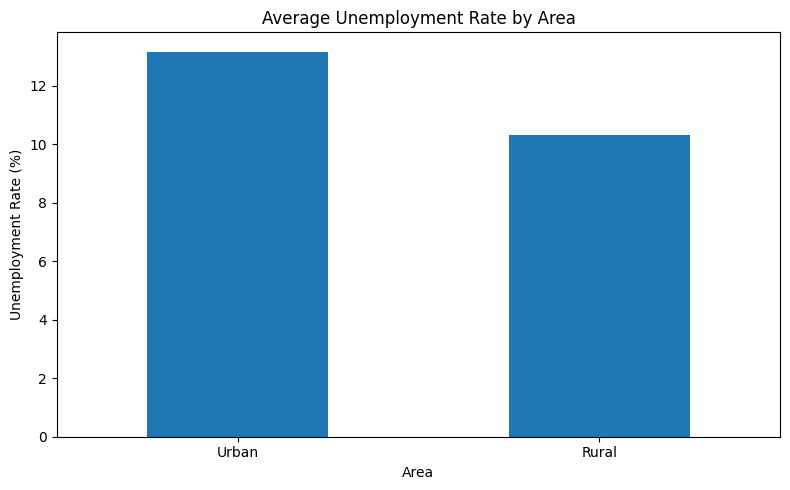

In [23]:
plt.figure(figsize=(8, 5))

area_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Area')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
df['COVID Period'] = np.where(
    df['Date'] < pd.Timestamp('2020-03-01'),
    'Before COVID-19',
    'During COVID-19'
)

covid_analysis = (
    df.groupby('COVID Period')['Estimated Unemployment Rate (%)']
    .mean()
)

print(covid_analysis)

COVID Period
Before COVID-19     9.509534
During COVID-19    17.774363
Name: Estimated Unemployment Rate (%), dtype: float64


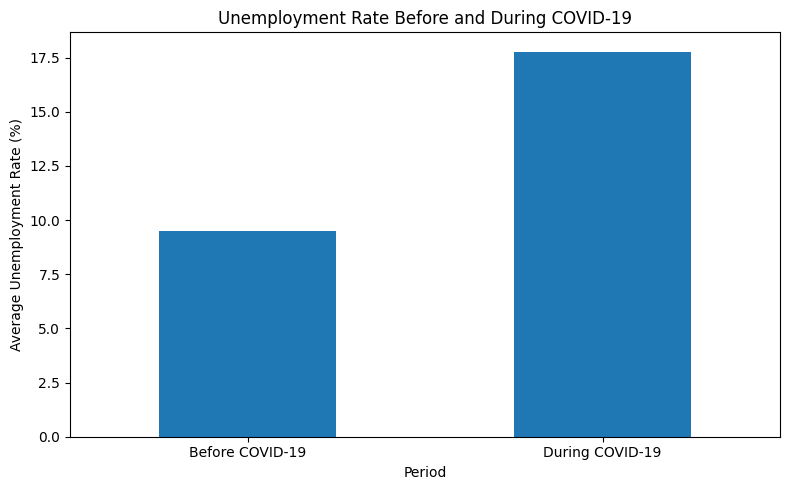

In [25]:
plt.figure(figsize=(8, 5))

covid_analysis.plot(kind='bar')

plt.title('Unemployment Rate Before and During COVID-19')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

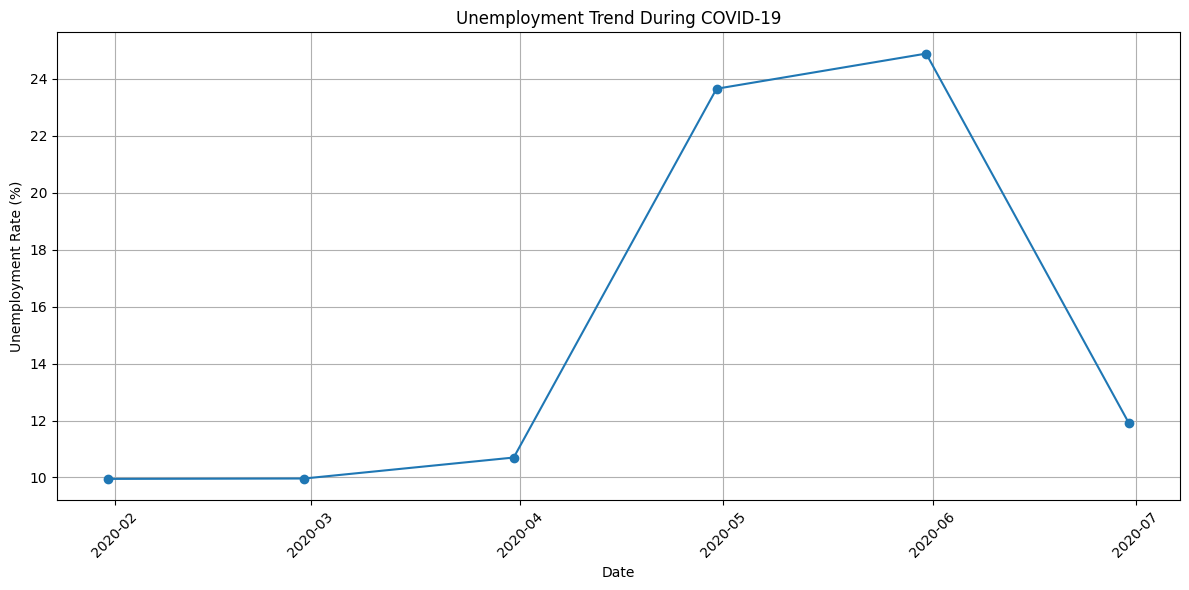

In [26]:
covid_data = df[
    df['Date'] >= pd.Timestamp('2020-01-01')
]

covid_monthly = (
    covid_data.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    covid_monthly['Date'],
    covid_monthly['Estimated Unemployment Rate (%)'],
    marker='o'
)

plt.title('Unemployment Trend During COVID-19')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
employment_by_region = (
    df.groupby('Region')['Estimated Employed']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Regions by Average Employment:")
print(employment_by_region.head(10))

Top 10 Regions by Average Employment:
Region
Uttar Pradesh     2.809483e+07
Maharashtra       1.999020e+07
West Bengal       1.719854e+07
Bihar             1.236619e+07
Tamil Nadu        1.226955e+07
Gujarat           1.140201e+07
Madhya Pradesh    1.111548e+07
Karnataka         1.066712e+07
Rajasthan         1.004106e+07
Andhra Pradesh    8.154093e+06
Name: Estimated Employed, dtype: float64


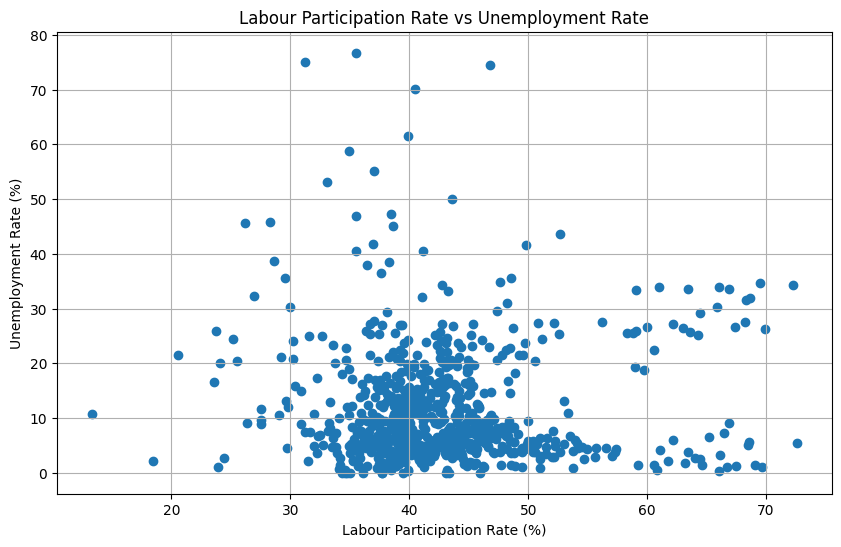

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Estimated Labour Participation Rate (%)'],
    df['Estimated Unemployment Rate (%)']
)

plt.title('Labour Participation Rate vs Unemployment Rate')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')

plt.grid(True)
plt.show()

In [29]:
correlation = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


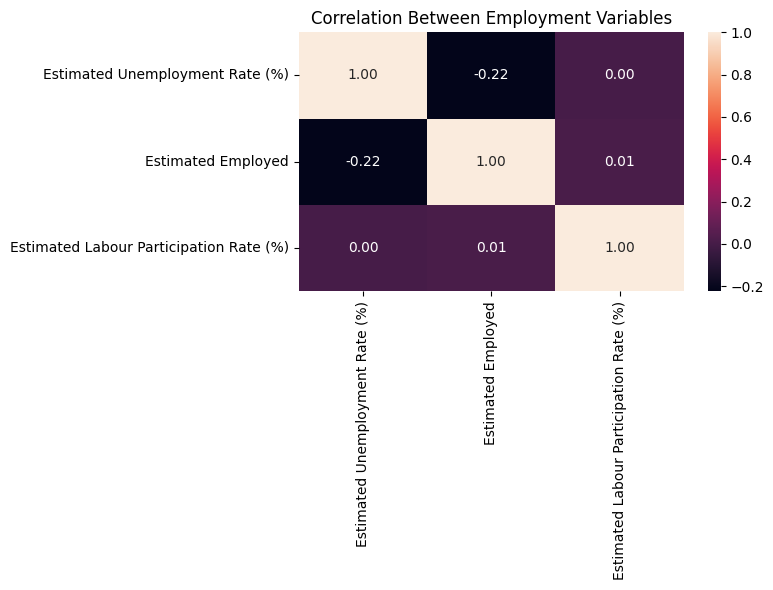

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Employment Variables')
plt.tight_layout()
plt.show()

In [31]:
highest = df.loc[
    df['Estimated Unemployment Rate (%)'].idxmax()
]

print("Highest Unemployment Record:")
print(highest)

Highest Unemployment Record:
Region                                              Puducherry
Date                                       2020-04-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                          76.74
Estimated Employed                                     68122.0
Estimated Labour Participation Rate (%)                  35.54
Area                                                     Urban
COVID Period                                   During COVID-19
Name: 627, dtype: object


In [32]:
lowest = df.loc[
    df['Estimated Unemployment Rate (%)'].idxmin()
]

print("Lowest Unemployment Record:")
print(lowest)

Lowest Unemployment Record:
Region                                                   Assam
Date                                       2020-06-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                            0.0
Estimated Employed                                   7544937.0
Estimated Labour Participation Rate (%)                  34.38
Area                                                     Rural
COVID Period                                   During COVID-19
Name: 25, dtype: object


In [33]:
print("========== UNEMPLOYMENT ANALYSIS SUMMARY ==========")

print(
    "Average Unemployment Rate:",
    round(df['Estimated Unemployment Rate (%)'].mean(), 2),
    "%"
)

print(
    "Highest Unemployment Rate:",
    round(df['Estimated Unemployment Rate (%)'].max(), 2),
    "%"
)

print(
    "Lowest Unemployment Rate:",
    round(df['Estimated Unemployment Rate (%)'].min(), 2),
    "%"
)

print(
    "\nRegion with Highest Average Unemployment:",
    region_unemployment.idxmax()
)

print(
    "Highest Regional Average:",
    round(region_unemployment.max(), 2),
    "%"
)

print("\nCOVID-19 Analysis:")
print(covid_analysis)

========== UNEMPLOYMENT ANALYSIS SUMMARY ==========
Average Unemployment Rate: 11.79 %
Highest Unemployment Rate: 76.74 %
Lowest Unemployment Rate: 0.0 %

Region with Highest Average Unemployment: Tripura
Highest Regional Average: 28.35 %

COVID-19 Analysis:
COVID Period
Before COVID-19     9.509534
During COVID-19    17.774363
Name: Estimated Unemployment Rate (%), dtype: float64
